<a href="https://colab.research.google.com/github/smndbkv/Linear-model-ml/blob/main/BinClass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from matplotlib.typing import ColorType
import matplotlib.pyplot as plt
import random

In [ ]:
N = 400
x0 = np.random.uniform(0, 1, N)
x1 = np.random.uniform(0, 1, N)
eps = np.random.normal(-0.2, 0.2, N)
y0 = np.zeros(N)
y1 = np.zeros(N)
for i in range(0,N):
  y0[i] = (x0[i])**2+ eps[i]
  y1[i] = (x1[i])**2+ eps[i]+1

N2 = 2*N
X = np.zeros((N2,3))
for i in range(0, N):
  X[i] = [x0[i], y0[i], -1]
  X[i+N] = [x1[i], y1[i], 1]
N = N2
np.random.shuffle(X)
N

800

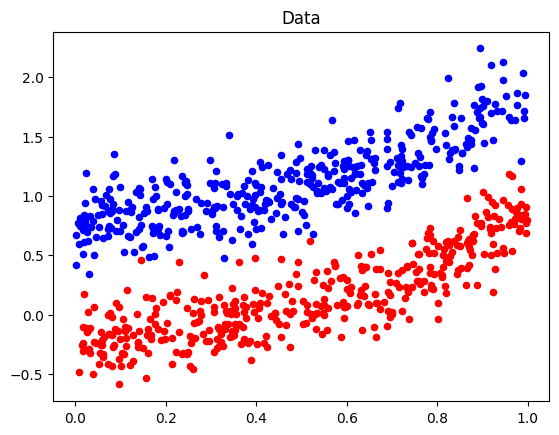

In [ ]:
plt.scatter(x0, y0, c = 'red',s=20)
plt.scatter(x1, y1, c = 'blue',s=20)
plt.title("Data")
plt.show()

In [ ]:
def model(w0, w1, w2, x, y):
  return w2*y + w1*x + w0

def theta(x):
  if(x > 0):
    return 1
  else:
    return 0
def L(w0,w1,w2,X,N): # Hinge
  sum = 0
  for j in range(0,N):
    sum += max(0, 1-X[j][2]*model(w0,w1,w2,X[j][0],X[j][1]))
  return sum
def grad_L(w0, w1, w2, X, N):
  sum0 = 0
  sum1 = 0
  sum2 = 0
  for j in range(0,N):
    sum0 -= X[j][2]*theta(1-X[j][2]*model(w0,w1,w2,X[j][0],X[j][1]))
    sum1 -= X[j][2]*X[j][0]*theta(1-X[j][2]*model(w0,w1,w2,X[j][0],X[j][1]))
    sum2 -= X[j][2]*X[j][1]*theta(1-X[j][2]*model(w0,w1,w2,X[j][0],X[j][1]))
  return sum0, sum1, sum2
def stochastic_grad_L(w0, w1, w2, X, batch, k):
  sum0 = 0
  sum1 = 0
  sum2 = 0
  for j in range(k*batch,(k+1)*batch):
    sum0 -= X[j][2]*theta(1-X[j][2]*model(w0,w1,w2,X[j][0],X[j][1]))
    sum1 -= X[j][2]*X[j][0]*theta(1-X[j][2]*model(w0,w1,w2,X[j][0],X[j][1]))
    sum2 -= X[j][2]*X[j][1]*theta(1-X[j][2]*model(w0,w1,w2,X[j][0],X[j][1]))
  return sum0, sum1, sum2

In [ ]:
# GD - Gradient descent
w0 = w1 = w2 = 1
alpha = 0.01
epoch = 500
for i in range(0, epoch):
  w = grad_L(w0, w1, w2, X, N)
  w0 = w0 - alpha * w[0]
  w1 = w1 - alpha * w[1]
  w2 = w2 - alpha * w[2]
w0, w1, w2


(np.float64(-1.7),
 np.float64(-9.075711688054247),
 np.float64(9.099643631490009))

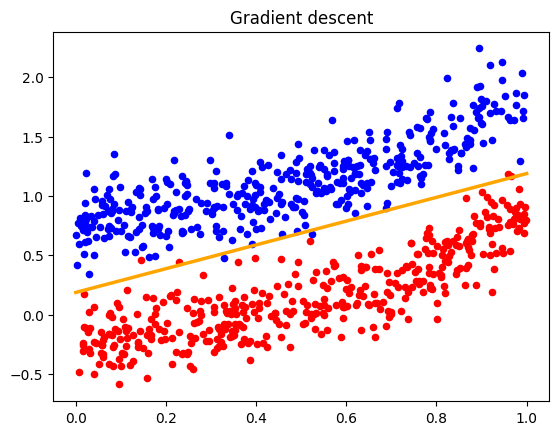

Loss : 15.516596471216092


In [ ]:
plt.scatter(x0, y0, c = 'red',s=20)
plt.scatter(x1, y1, c = 'blue',s=20)
plt.plot([0, 1], [-w0 / w2, -(w1+w0) / w2], c = 'orange', linewidth = 2.5)
plt.title("Gradient descent")
plt.show()
print("Loss :", L(w0,w1,w2,X,N))

In [ ]:
# SGD - Stochastic gradient descent
w0 = w1 = 0
alpha = 0.01
epoch = 200
batch = 40
for i in range(0, epoch):
  np.random.shuffle(X)
  for j in range(0, int(N / batch)):
    w = stochastic_grad_L(w0,w1,w2,X,batch,j)
    w0 = w0 - alpha * w[0]
    w1 = w1 - alpha * w[1]
w0, w1

(np.float64(-1.7000000000000188), np.float64(-9.119971991337477))

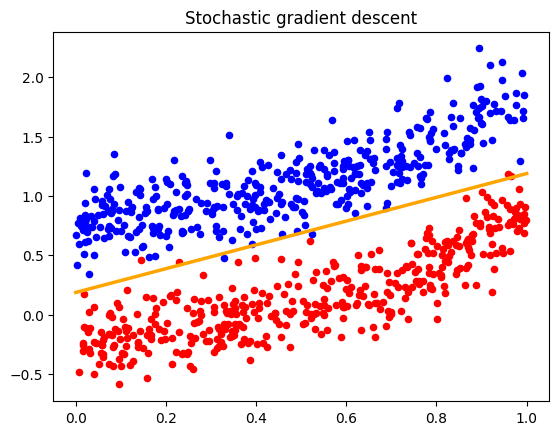

Loss : 15.516596471216092


In [ ]:
plt.scatter(x0, y0, c = 'red',s=20)
plt.scatter(x1, y1, c = 'blue',s=20)
plt.plot([0, 1], [-w0 / w2, -(w1+w0) / w2], c = 'orange', linewidth = 2.5)
plt.title("Stochastic gradient descent")
plt.show()
print("Loss :", L(w0,w1,w2,X,N))